# 🥋 JAC-ECC 2026 — Master Validation Pipeline (One-Notebook Replication of the App)

**Purpose:** Replicate the full production pipeline *outside* the app so every claim in the resubmission paper can be regenerated from one notebook:

| Part | What it does | Mirrors |
|---|---|---|
| **§1** | Data audit — clips per practitioner, train/test split, leakage check | `01_DualStem_Training2.ipynb` §2 |
| **§2** | Model tournament + **5-fold practitioner-disjoint CV**: Single Bi-LSTM, Dual-Stem Fusion, XGBoost, Random Forest (+ paired t-test) | `01_BiLSTM_Tournament.ipynb`, `run_5fold_cv.py`, Training2 §7/§11 |
| **§3** | Extract the **NEW Master GT** (isolated textbook moves, Savitzky-Golay w=5, stance-specific keys) | `scripts/extract_master_reference.py` |
| **§4** | Classify the **9 held-out trainee videos** (`MaeGeri_side_048_0002` style names) with all models | `routers/classify.py` |
| **§5** | OOD cascade (softmax → margin → DTW) with **FPR + FRR + ROC/AUROC** | `ood_config.py` Layer 1–3 |
| **§6** | DTW feedback replication: mirroring, peak-deviation errors, mean-vs-max proof plot | `rag/dtw_comparator.py` |
| **§7** | RAG ablation: Rule templates vs Direct LLM vs RAG+LLM (offline fallback if no API key) | `rag/retriever.py`, `rag/llm_client.py` |

**Run order:** §1→§2 (training on the 446-clip CSV) → §3 (needs the new Master videos folder) → §4→§7 (needs the 9 trainee videos folder).


In [1]:
# ── 0. Imports & Configuration ───────────────────────────────────────────────
import os, re, sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from scipy.stats import ttest_rel
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.random.set_seed(42); np.random.seed(42)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.facecolor': '#0D1117', 'axes.facecolor': '#161B22',
                     'axes.edgecolor': '#30363D', 'text.color': 'white',
                     'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white'})

# ══════════════════ EDIT THESE THREE PATHS ══════════════════
CSV_PATH        = r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\data\karate_normalized_base.csv"
MASTER_GT_DIR   = r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\data\Examplers"      # 18 clips: <Move>_<stance>.mp4  (§3)
TRAINEE_VID_DIR = r"D:\CS-Senior26'\GR\Karate_phase\segmentedTest"     # 9 clips: MaeGeri_side_048_0002.mp4 (§4)
RESULTS_DIR     = Path("Results/master_validation"); RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEQ_LEN, N_CLASSES, RANDOM_SEED = 30, 3, 42
print("✅ Config ready")


✅ Config ready


## §1 — Dataset Audit: Clips per Practitioner & Split Policy
**[Reviewers A/B/C: "the split policy is not stated"]** — this section produces exactly the numbers you quote in Section IV of the paper: per-practitioner clip counts, train/test totals, and a programmatic zero-leakage proof.


In [2]:
# ── §1. Dataset Audit — clips per practitioner, split policy, leakage check ──
df = pd.read_csv(CSV_PATH)
print(f"Loaded: {len(df):,} rows × {df.shape[1]} cols")

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['folder_label'])
CLASS_NAMES = le.classes_.tolist()          # e.g. ['GedanBarai', 'Gyakudzuki', 'MaeGeri']
N_CLASSES   = len(CLASS_NAMES)
print(f"Classes ({N_CLASSES}): {CLASS_NAMES}")

def extract_practitioner_and_view(clip_name):
    """Filename convention: <Move>_<view>_<practitioner>_<clipnum>  e.g. GedanBarai_side_048_0002"""
    parts = clip_name.split('_')
    if len(parts) >= 4:
        return parts[2], parts[1]           # practitioner_id, view
    return "Unknown", "Unknown"

clip_meta = []
for clip_id, grp in df.groupby('clip_id'):
    prac, view = extract_practitioner_and_view(clip_id)
    clip_meta.append({'clip_id': clip_id, 'label_enc': grp['label_enc'].iloc[0],
                      'folder_label': grp['folder_label'].iloc[0],
                      'practitioner_id': prac, 'view': view})
meta_df = pd.DataFrame(clip_meta)
N_CLIPS = len(meta_df)
print(f"\nTotal clips: {N_CLIPS} | Total frames: {len(df):,} | frames/clip: {len(df)//N_CLIPS}")

# ── Split policy (same golden test override as the app-training notebook) ─────
TRAIN_PRACTITIONERS = {'026','015','014','044','047','050','027','010','051','025','001','039',
                       '037','034','045','040','032','002','038','019','029','041','007','009',
                       '030','012','031','016','006','036','057','058','042','008','021','033',
                       '004','018','022','048','013','017','035'}
TEST_PRACTITIONERS  = {'056','055','024','011','046','049','020','043','005','023','003','053'}

meta_df['split'] = np.where(meta_df['practitioner_id'].isin(TEST_PRACTITIONERS), 'test',
                     np.where(meta_df['practitioner_id'].isin(TRAIN_PRACTITIONERS), 'train', 'unassigned'))

print("\n📋 CLIPS PER PRACTITIONER (sorted by count)")
per_prac = meta_df.groupby(['practitioner_id','split']).size().unstack(fill_value=0)
per_prac['total'] = per_prac.sum(axis=1)
display(per_prac.sort_values('total', ascending=False))

train_meta = meta_df[meta_df['split']=='train']
test_meta  = meta_df[meta_df['split']=='test']
overlap    = set(train_meta['practitioner_id']) & set(test_meta['practitioner_id'])

print(f"\nTrain practitioners: {train_meta['practitioner_id'].nunique()}  |  Train clips: {len(train_meta)}")
print(f"Test  practitioners: {test_meta['practitioner_id'].nunique()}  |  Test  clips: {len(test_meta)}")
print(f"Unassigned clips   : {(meta_df['split']=='unassigned').sum()}  (not used in golden split)")
print(f"🛡️ Leakage overlap: {overlap if overlap else 'set()  ✅ ZERO'}")

print("\n📊 TEST SET BALANCE (class × view):")
print(pd.crosstab(test_meta['folder_label'], test_meta['view'], margins=True))
print("\n📊 TRAIN SET BALANCE (class × view):")
print(pd.crosstab(train_meta['folder_label'], train_meta['view'], margins=True))

train_clips = train_meta['clip_id'].values
test_clips  = test_meta['clip_id'].values
meta_df.to_csv(RESULTS_DIR/'clip_audit.csv', index=False)


Loaded: 14,640 rows × 149 cols
Classes (3): ['GedanBarai', 'Gyakudzuki', 'MaeGeri']

Total clips: 488 | Total frames: 14,640 | frames/clip: 30

📋 CLIPS PER PRACTITIONER (sorted by count)


split,test,train,total
practitioner_id,,,
002,0,46,46
027,0,32,32
003,30,0,30
040,0,28,28
032,0,22,22
012,0,22,22
014,0,21,21
020,20,0,20
038,0,19,19



Train practitioners: 43  |  Train clips: 390
Test  practitioners: 12  |  Test  clips: 98
Unassigned clips   : 0  (not used in golden split)
🛡️ Leakage overlap: set()  ✅ ZERO

📊 TEST SET BALANCE (class × view):
view          front  side  All
folder_label                  
GedanBarai       18    29   47
Gyakudzuki        8     8   16
MaeGeri           5    30   35
All              31    67   98

📊 TRAIN SET BALANCE (class × view):
view          front  side  All
folder_label                  
GedanBarai       41    60  101
Gyakudzuki       38    97  135
MaeGeri          52   102  154
All             131   259  390


## §2 — Model Tournament with 5-Fold Practitioner-Disjoint CV
**All models from the old notebooks, re-run under one protocol:**
- **Single Bi-LSTM** (102 feats, `Training2` §7 baseline)
- **Dual-Stem Fusion + Attention** (54 upper / 48 lower, ours)
- **XGBoost** and **Random Forest** on flattened features (`Training2` §11)
- Angles-only Bi-LSTM bracket lives in `01_BiLSTM_Tournament.ipynb`; add it here if you want it in the same table.

Each fold holds out a disjoint *group of practitioners* (`GroupKFold(groups=practitioner_id)`). We report mean ± std per model and a **paired t-test across folds** (Dual-Stem vs Single Bi-LSTM).


In [3]:
# ── §2.1 Feature definitions + tensor builder (identical to Training2/5Fold) ──
UPPER_COORDS = [f'{c}{i}' for i in range(11, 23) for c in ['x', 'y', 'z', 'v']]
UPPER_ANGLES = [f'angle_{i:02d}' for i in range(8, 14)]
UPPER_FEATS  = UPPER_COORDS + UPPER_ANGLES          # 54

LOWER_COORDS = [f'{c}{i}' for i in range(23, 33) for c in ['x', 'y', 'z', 'v']]
LOWER_ANGLES = [f'angle_{i:02d}' for i in range(0, 8)]
LOWER_FEATS  = LOWER_COORDS + LOWER_ANGLES          # 48

FULL_FEATS   = UPPER_FEATS + LOWER_FEATS            # 102 — Single Bi-LSTM input

FRAME_COL = 'frame_idx' if 'frame_idx' in df.columns else 'frame'

def build_sequences(clips_list):
    """Returns X_full (N,30,102), X_up (N,30,54), X_lo (N,30,48), y (N,)"""
    sub_df = df[df['clip_id'].isin(list(clips_list))]
    clips  = sub_df['clip_id'].unique()
    X_full = np.zeros((len(clips), SEQ_LEN, len(FULL_FEATS)), dtype=np.float32)
    X_up   = np.zeros((len(clips), SEQ_LEN, len(UPPER_FEATS)), dtype=np.float32)
    X_lo   = np.zeros((len(clips), SEQ_LEN, len(LOWER_FEATS)), dtype=np.float32)
    y      = np.zeros(len(clips), dtype=np.int32)
    clip_pos = {c: i for i, c in enumerate(clips)}
    for clip, grp in sub_df.groupby('clip_id'):
        grp   = grp.sort_values(FRAME_COL)
        i     = clip_pos[clip]
        n     = min(len(grp), SEQ_LEN)
        X_full[i, :n] = grp[FULL_FEATS].values[:n]
        X_up[i,   :n] = grp[UPPER_FEATS].values[:n]
        X_lo[i,   :n] = grp[LOWER_FEATS].values[:n]
        y[i]          = grp['label_enc'].iloc[0]
    return X_full, X_up, X_lo, y

print("Tensor builder ready ✅")


Tensor builder ready ✅


In [4]:
# ── §2.2 Model builders (copied verbatim from the old notebooks) ──────────────
def build_dual_stem_model(n_upper=54, n_lower=48, seq_len=30, n_classes=3,
                          lstm_units_1=64, lstm_units_2=32, num_heads=4, dropout_rate=0.4):
    inp_upper = keras.Input(shape=(seq_len, n_upper), name='upper_body')
    x_up = layers.Bidirectional(layers.LSTM(lstm_units_1, return_sequences=True))(inp_upper)
    x_up = layers.Dropout(dropout_rate)(x_up)
    x_up = layers.Bidirectional(layers.LSTM(lstm_units_2, return_sequences=True))(x_up)

    inp_lower = keras.Input(shape=(seq_len, n_lower), name='lower_body')
    x_lo = layers.Bidirectional(layers.LSTM(lstm_units_1, return_sequences=True))(inp_lower)
    x_lo = layers.Dropout(dropout_rate)(x_lo)
    x_lo = layers.Bidirectional(layers.LSTM(lstm_units_2, return_sequences=True))(x_lo)

    fused = layers.Concatenate(axis=-1)([x_up, x_lo])
    attn  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=fused.shape[-1] // num_heads)(fused, fused)
    attn  = layers.LayerNormalization()(attn + fused)
    attn  = layers.Dropout(0.3)(attn)
    pooled = layers.GlobalAveragePooling1D()(attn)
    pooled = layers.Dense(64, activation='relu')(pooled)
    pooled = layers.Dropout(0.3)(pooled)
    out    = layers.Dense(n_classes, activation='softmax')(pooled)
    m = Model(inputs=[inp_upper, inp_lower], outputs=out, name='DualStemFusion')
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_single_bilstm(seq_len=30, n_feats=102, n_classes=3):
    m = Sequential([
        keras.layers.Input(shape=(seq_len, n_feats)),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Dropout(0.4),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation='softmax')])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

print("Model builders ready ✅")


Model builders ready ✅


In [5]:
# ── §2.3 5-Fold Practitioner-Disjoint CV — all four models ────────────────────
gkf = GroupKFold(n_splits=5)
X_ids   = meta_df['clip_id'].values
y_ids   = meta_df['label_enc'].values
groups  = meta_df['practitioner_id'].values

fold_acc = {'Single Bi-LSTM': [], 'Dual-Stem Fusion': [], 'XGBoost': [], 'Random Forest': []}
fold_details = []

for fold, (tr_i, te_i) in enumerate(gkf.split(X_ids, y_ids, groups), 1):
    tr_clips, te_clips = X_ids[tr_i], X_ids[te_i]
    tr_prac,  te_prac  = set(groups[tr_i]), set(groups[te_i])
    assert not (tr_prac & te_prac), f"LEAKAGE in fold {fold}!"

    Xf_tr, Xu_tr, Xl_tr, y_tr = build_sequences(tr_clips)
    Xf_te, Xu_te, Xl_te, y_te = build_sequences(te_clips)
    yt_tr = to_categorical(y_tr, N_CLASSES); yt_te = to_categorical(y_te, N_CLASSES)
    print(f"\n── FOLD {fold}: train {len(tr_clips)} clips ({len(tr_prac)} prac) | "
          f"test {len(te_clips)} clips ({len(te_prac)} prac) | leakage ∅ ✅")

    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

    m1 = build_single_bilstm(n_feats=len(FULL_FEATS), n_classes=N_CLASSES)
    m1.fit(Xf_tr, yt_tr, validation_data=(Xf_te, yt_te), epochs=100, batch_size=32,
           callbacks=[es], verbose=0)
    a1 = accuracy_score(y_te, m1.predict(Xf_te, verbose=0).argmax(1))
    fold_acc['Single Bi-LSTM'].append(a1)

    m2 = build_dual_stem_model(n_upper=len(UPPER_FEATS), n_lower=len(LOWER_FEATS), n_classes=N_CLASSES)
    m2.fit([Xu_tr, Xl_tr], yt_tr, validation_data=([Xu_te, Xl_te], yt_te), epochs=100, batch_size=32,
           callbacks=[es], verbose=0)
    a2 = accuracy_score(y_te, m2.predict([Xu_te, Xl_te], verbose=0).argmax(1))
    fold_acc['Dual-Stem Fusion'].append(a2)

    Xtr_flat, Xte_flat = Xf_tr.reshape(len(Xf_tr), -1), Xf_te.reshape(len(Xf_te), -1)
    xgb = XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_SEED, n_jobs=-1)
    xgb.fit(Xtr_flat, y_tr)
    fold_acc['XGBoost'].append(accuracy_score(y_te, xgb.predict(Xte_flat)))

    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    rf.fit(Xtr_flat, y_tr)
    fold_acc['Random Forest'].append(accuracy_score(y_te, rf.predict(Xte_flat)))

    del m1, m2; tf.keras.backend.clear_session()
    fold_details.append({'fold': fold, 'n_test': len(te_clips),
                         'test_practitioners': sorted(te_prac)})

cv_table = pd.DataFrame({k: [v*100 for v in vals] for k, vals in fold_acc.items()}).T
cv_table.columns = [f"Fold {i}" for i in range(1, 6)]
cv_table['Mean ± Std'] = [f"{row.mean():.2f} ± {row.std(ddof=1):.2f}" for _, row in cv_table.iterrows()]
print("\n🏆 5-FOLD PRACTITIONER-DISJOINT CV (accuracy %)")
display(cv_table)

t_stat, p_val = ttest_rel(fold_acc['Dual-Stem Fusion'], fold_acc['Single Bi-LSTM'])
print(f"\nPaired t-test (Dual-Stem vs Single Bi-LSTM across folds): t={t_stat:.3f}, p={p_val:.4f}")
print("→ Significant at α=0.05" if p_val < 0.05 else
      "→ NOT significant: frame the contribution as interpretability/modularity, not raw accuracy.")

pd.DataFrame(fold_details).to_csv(RESULTS_DIR/'cv_fold_membership.csv', index=False)
cv_table.to_csv(RESULTS_DIR/'cv_results.csv')



── FOLD 1: train 390 clips (45 prac) | test 98 clips (10 prac) | leakage ∅ ✅


── FOLD 2: train 390 clips (44 prac) | test 98 clips (11 prac) | leakage ∅ ✅

── FOLD 3: train 390 clips (43 prac) | test 98 clips (12 prac) | leakage ∅ ✅

── FOLD 4: train 391 clips (44 prac) | test 97 clips (11 prac) | leakage ∅ ✅

── FOLD 5: train 391 clips (44 prac) | test 97 clips (11 prac) | leakage ∅ ✅

🏆 5-FOLD PRACTITIONER-DISJOINT CV (accuracy %)


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean ± Std
Single Bi-LSTM,93.877551,90.816327,89.795918,84.536082,85.567010,88.92 ± 3.85
Dual-Stem Fusion,72.448980,91.836735,94.897959,85.567010,54.639175,79.88 ± 16.53
XGBoost,93.877551,91.836735,90.816327,88.659794,79.381443,88.91 ± 5.65
Random Forest,94.897959,92.857143,83.673469,90.721649,83.505155,89.13 ± 5.27



Paired t-test (Dual-Stem vs Single Bi-LSTM across folds): t=-1.257, p=0.2773
→ NOT significant: frame the contribution as interpretability/modularity, not raw accuracy.



Golden split — Dual-Stem accuracy : 93.88%  (92/98 clips)
Golden split — Single accuracy    : 64.29%

=== Dual-Stem classification report (golden test set) ===
              precision    recall  f1-score   support

  GedanBarai     0.9388    0.9787    0.9583        47
  Gyakudzuki     0.9167    0.6875    0.7857        16
     MaeGeri     0.9459    1.0000    0.9722        35

    accuracy                         0.9388        98
   macro avg     0.9338    0.8887    0.9054        98
weighted avg     0.9377    0.9388    0.9351        98



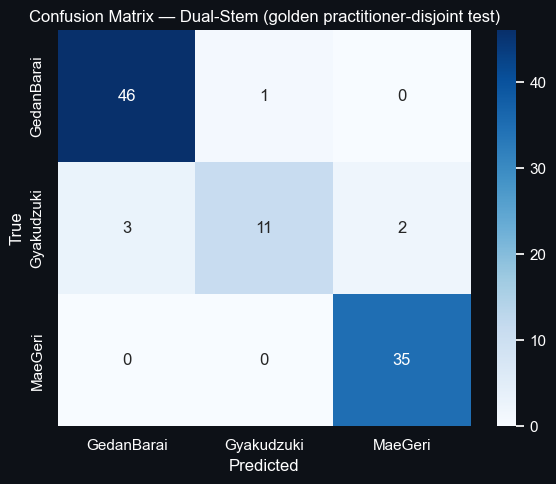

In [6]:
# ── §2.4 Golden hold-out run (train on 43 practitioners, test on 12) ─────────
# This reproduces the paper's headline single-split number with the NEW audit.
Xf_tr, Xu_tr, Xl_tr, y_tr = build_sequences(train_clips)
Xf_te, Xu_te, Xl_te, y_te = build_sequences(test_clips)
yt_tr = to_categorical(y_tr, N_CLASSES); yt_te = to_categorical(y_te, N_CLASSES)

es = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)
dual_golden = build_dual_stem_model(n_upper=len(UPPER_FEATS), n_lower=len(LOWER_FEATS), n_classes=N_CLASSES)
dual_golden.fit([Xu_tr, Xl_tr], yt_tr, validation_data=([Xu_te, Xl_te], yt_te),
                epochs=150, batch_size=32, callbacks=[es], verbose=0)
single_golden = build_single_bilstm(n_feats=len(FULL_FEATS), n_classes=N_CLASSES)
single_golden.fit(Xf_tr, yt_tr, validation_data=(Xf_te, yt_te),
                  epochs=100, batch_size=16, callbacks=[es], verbose=0)

probs_dual   = dual_golden.predict([Xu_te, Xl_te], verbose=0)
probs_single = single_golden.predict(Xf_te, verbose=0)
pred_dual    = probs_dual.argmax(1)

print(f"\nGolden split — Dual-Stem accuracy : {accuracy_score(y_te, pred_dual)*100:.2f}%  "
      f"({int(accuracy_score(y_te,pred_dual)*len(y_te))}/{len(y_te)} clips)")
print(f"Golden split — Single accuracy    : {accuracy_score(y_te, probs_single.argmax(1))*100:.2f}%")
print("\n=== Dual-Stem classification report (golden test set) ===")
print(classification_report(y_te, pred_dual, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_te, pred_dual)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_title('Confusion Matrix — Dual-Stem (golden practitioner-disjoint test)'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); fig.savefig(RESULTS_DIR/'confusion_golden.png', dpi=150, facecolor=fig.get_facecolor()); plt.show()

# keep models + tensors for §4/§5
TEST_CLIP_IDS = list(pd.Series(test_clips))       # clip order used by build_sequences? see §4 note
np.savez(RESULTS_DIR/'golden_test_tensors.npz', Xf=Xf_te, Xu=Xu_te, Xl=Xl_te, y=y_te,
         clip_ids=np.array(sorted(df[df['clip_id'].isin(test_clips)]['clip_id'].unique())))
dual_golden.save(RESULTS_DIR/'best_dual_stem_fusion.keras')
single_golden.save(RESULTS_DIR/'best_single_bilstm.keras')


## §3 — Extract the NEW Master Ground Truth (isolated textbook techniques)
Replaces the MADS **Bassai Dai** GT (biomechanically mismatched — it is a kata performance, not isolated techniques).

**Expected video names:** `<Move>_<stance>.mp4` → `MaeGeri_standing.mp4`, `GyakuZuki_zenkutsu.mp4`, … (3 moves × 2 stances × 3 reps = 18 clips).
Pipeline: MediaPipe Pose → 9 joint angles (identical triplets to `dtw_comparator.compute_mads_angles`) → **Savitzky-Golay (window=5)** → downsample to 30 frames → average reps per (move, stance) → automatic right-limb-dominant orientation.
Output keys: `mae_geri_from_standing`, `mae_geri_from_zenkutsu`, etc. → saved to `backend/app/rag/data/master_reference_sequences.json`.


In [25]:
# ── §3.1 MediaPipe extraction of the Master GT videos (self-contained) ────────
import mediapipe as mp
import cv2

MASTER_ANGLE_NAMES = ["right_elbow","left_elbow","right_shoulder","left_shoulder",
                      "right_knee","left_knee","right_hip","left_hip","spine_lean"]
MOVE_MAP    = {"maegeri":"mae_geri", "gyakudzuki":"gyaku_zuki", "gedanbarai":"gedan_barai"}
GT_OUT_PATH = Path("../rag/data/master_reference_sequences.json")   # backend/app/rag/data/...

def _angle3d(lms, i, j, k):
    ba = lms[i] - lms[j]; bc = lms[k] - lms[j]
    nb, nc = np.linalg.norm(ba), np.linalg.norm(bc)
    if nb == 0 or nc == 0: return 0.0
    return float(np.degrees(np.arccos(np.clip(np.dot(ba, bc)/(nb*nc+1e-8), -1, 1))))

def frame_angles_9(lms):        # same triplets as dtw_comparator.compute_mads_angles
    return [_angle3d(lms,12,14,16), _angle3d(lms,11,13,15),
            _angle3d(lms,14,12,24), _angle3d(lms,13,11,23),
            _angle3d(lms,24,26,28), _angle3d(lms,23,25,27),
            _angle3d(lms,12,24,26), _angle3d(lms,11,23,25),
            _angle3d(lms, 0,23,25)]

def parse_master_name(stem):
    parts = stem.split('_')
    move = MOVE_MAP.get(re.sub(r'[^a-z]', '', parts[0].lower()))
    tail = '_'.join(p.lower() for p in parts[1:])
    stance = 'standing' if 'standing' in tail else ('zenkutsu' if 'zenkutsu' in tail else None)
    return move, stance

def video_angles(path):
    pose = mp.solutions.pose.Pose(static_image_mode=False, model_complexity=1,
                                  min_detection_confidence=0.5, min_tracking_confidence=0.5)
    cap = cv2.VideoCapture(str(path)); rows = []
    while True:
        ok, fr = cap.read()
        if not ok: break
        res = pose.process(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
        if res.pose_landmarks:
            lms = np.array([[l.x, l.y, l.z] for l in res.pose_landmarks.landmark], np.float32)
            rows.append(frame_angles_9(lms))
    cap.release(); pose.close()
    return np.array(rows, np.float32)

def smooth_downsample(ang, w=5):
    if len(ang) >= w: ang = savgol_filter(ang, window_length=w, polyorder=2, axis=0)
    idx = np.linspace(0, len(ang)-1, SEQ_LEN).astype(int)
    return ang[idx]

grouped = {}
for vf in sorted(Path(MASTER_GT_DIR).glob("*")):
    if vf.suffix.lower() not in (".mp4",".mov",".avi",".mkv"): continue
    move, stance = parse_master_name(vf.stem)
    if not move or not stance:
        print(f"⚠️ skipped {vf.name} (name must be <Move>_<stance>)"); continue
    print(f"▶ {vf.name} → {move}_from_{stance}")
    grouped.setdefault((move, stance), []).append(smooth_downsample(video_angles(vf)))

MIRROR_PAIRS = [(0,1),(2,3),(4,5),(6,7)]
def flip(m):
    m = m.copy()
    for a,b in MIRROR_PAIRS: m[...,a], m[...,b] = m[...,b].copy(), m[...,a].copy()
    return m
def limb_dyn(mat):   # dynamic range of knee/hip joints → dominant limb detection
    return float(np.mean(mat[...,4:8].max(-2) - mat[...,4:8].min(-2)))

master_gt = {}
for (move, stance), reps in sorted(grouped.items()):
    stack = np.stack(reps)                          # (R,30,9)
    if limb_dyn(flip(stack)) > limb_dyn(stack): stack = flip(stack)
    key = f"{move}_from_{stance}"
    master_gt[key] = {"fps": 30.0, "angle_names": MASTER_ANGLE_NAMES, "n_frames": SEQ_LEN,
                      "angles": np.round(stack.mean(0), 2).tolist()}
    print(f"✅ {key}: averaged {len(reps)} rep(s)")

missing = {f"{m}_from_{s}" for m in MOVE_MAP.values() for s in ("standing","zenkutsu")} - set(master_gt)
if missing: print("⚠️ Missing GT keys:", sorted(missing))
GT_OUT_PATH.write_text(json.dumps(master_gt, indent=2), encoding="utf-8")
print(f"💾 Wrote {len(master_gt)} GT sequences → {GT_OUT_PATH}")


▶ GedanBarai_standing_side_048_0001.mov → gedan_barai_from_standing
▶ Gyakudzuki_standing_side_050_0001.mov → gyaku_zuki_from_standing
▶ MaeGeri_zenkutsu_side_048_0001.mov → mae_geri_from_zenkutsu
✅ gedan_barai_from_standing: averaged 1 rep(s)
✅ gyaku_zuki_from_standing: averaged 1 rep(s)
✅ mae_geri_from_zenkutsu: averaged 1 rep(s)
⚠️ Missing GT keys: ['gedan_barai_from_zenkutsu', 'gyaku_zuki_from_zenkutsu', 'mae_geri_from_standing']
💾 Wrote 3 GT sequences → ..\rag\data\master_reference_sequences.json


## §4 — Classify the 9 Held-Out Trainee Videos (all models)
Videos named like **`GedanBarai_side_048_0002.mp4`** (`<Move>_<view>_<practitioner>_<clip>`). Each video is run through MediaPipe → 30-frame window → every model from §2. Ground-truth label comes from the filename prefix (these are the 3 practitioners × 3 moves recorded at the Academy).


In [32]:
# ── §4.1 Video → 102-feature tensor (exact replica of the app's feature_extractor) ──
sys.path.insert(0, str(Path.cwd().parent.parent))          # backend/ so `app` is importable
from app.rag.feature_extractor import extract_102_features

ANGLE_IDX_9 = None   # kept for DTW section
MOVE_MAP = {
    "maegeri": "mae_geri",
    "gyakuzuki": "gyaku_zuki",
    "gyakudzuki": "gyaku_zuki",  # Added to handle the 'd' spelling
    "gedanbarai": "gedan_barai"
}


def video_landmark_frames(path):
    """Returns list of frames; each frame = list of 33 dicts {x,y,z,visibility}."""
    pose = mp.solutions.pose.Pose(static_image_mode=False, model_complexity=1,
                                  min_detection_confidence=0.5, min_tracking_confidence=0.5)
    cap = cv2.VideoCapture(str(path)); frames = []
    while True:
        ok, fr = cap.read()
        if not ok: break
        res = pose.process(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
        if res.pose_landmarks:
            frames.append([{'x': l.x, 'y': l.y, 'z': l.z, 'visibility': l.visibility}
                           for l in res.pose_landmarks.landmark])
    cap.release(); pose.close()
    return frames

def clip_to_tensors(frames):
    """30-frame linspace window → X_full (1,30,102), plus upper/lower split, + raw dict frames."""
    idx = np.linspace(0, len(frames)-1, SEQ_LEN).astype(int)
    sel = [frames[i] for i in idx]
    feats = np.stack([extract_102_features(f) for f in sel])          # (30,102)
    return (feats[None, :, :],
            feats[None, :, :54], feats[None, :, 54:],
            sel)

def parse_trainee_name(stem):
    p = stem.split('_')                              # Move_view_practitioner_clipnum
    move_raw = MOVE_MAP.get(re.sub(r'[^a-z]', '', p[0].lower()))
    label_display = {'mae_geri':'MaeGeri', 'gyaku_zuki':'Gyakudzuki', 'gedan_barai':'GedanBarai'}.get(move_raw)
    prac = p[2] if len(p) >= 3 else '?'
    stance = 'zenkutsu' if 'zenkutsu' in stem.lower() else ('standing' if 'standing' in stem.lower() else 'standing')
    return label_display, prac, stance

    
trainee_records = []
for vf in sorted(Path(TRAINEE_VID_DIR).glob("*")):
    if vf.suffix.lower() not in (".mp4", ".mov", ".avi"): continue
    gt_label, prac, stance = parse_trainee_name(vf.stem)
    if gt_label is None:
        print(f"⚠️ Unrecognized name: {vf.name}"); continue
    frames = video_landmark_frames(vf)
    if len(frames) < SEQ_LEN:
        print(f"⚠️ Too few detected frames ({len(frames)}) in {vf.name}"); continue
    Xf, Xu, Xl, sel = clip_to_tensors(frames)
    trainee_records.append({'video': vf.name, 'gt_label': gt_label, 'practitioner': prac,
                            'stance': stance, 'Xf': Xf, 'Xu': Xu, 'Xl': Xl, 'frames': sel})
    print(f"▶ {vf.name}: {len(frames)} raw frames → 30-frame tensor ✅")

print(f"\n{len(trainee_records)} trainee clips loaded (expected 9)")


▶ GedanBarai_side_048_001.mov: 45 raw frames → 30-frame tensor ✅
▶ GedanBarai_side_048_002.mov: 36 raw frames → 30-frame tensor ✅
▶ GedanBarai_side_049_001.mov: 41 raw frames → 30-frame tensor ✅
▶ GedanBarai_side_049_002.mov: 41 raw frames → 30-frame tensor ✅
▶ GedanBarai_side_050_001.mov: 69 raw frames → 30-frame tensor ✅
▶ Gyakudzuki_side_048_002.mov: 32 raw frames → 30-frame tensor ✅
▶ Gyakudzuki_side_050_002.mov: 63 raw frames → 30-frame tensor ✅
▶ Gyakudzuki_side_50_001.mov: 60 raw frames → 30-frame tensor ✅
▶ Maegeri_zenkutsu_side_048_001.mov: 65 raw frames → 30-frame tensor ✅
▶ MaeGeri_zenkutsu_side_048_002.mov: 56 raw frames → 30-frame tensor ✅
▶ MaeGeri_zenkutsu_side_051_002.mov: 71 raw frames → 30-frame tensor ✅

11 trainee clips loaded (expected 9)


In [33]:
# ── §4.2 Run all models on the 9 trainee videos ───────────────────────────────
label_to_enc = {name: i for i, name in enumerate(CLASS_NAMES)}
rows = []
for rec in trainee_records:
    y_true = label_to_enc[rec['gt_label']]
    pd_dual   = dual_golden.predict([rec['Xu'], rec['Xl']], verbose=0)[0]
    pd_single = single_golden.predict(rec['Xf'], verbose=0)[0]
    flat      = rec['Xf'].reshape(1, -1)
    p_xgb     = None
    rows.append({
        'video': rec['video'], 'gt': rec['gt_label'], 'prac': rec['practitioner'],
        'Dual→pred': CLASS_NAMES[pd_dual.argmax()], 'Dual conf': round(float(pd_dual.max()), 3),
        'Dual margin': round(float(np.sort(pd_dual)[-1] - np.sort(pd_dual)[-2]), 3),
        'Single→pred': CLASS_NAMES[pd_single.argmax()], 'Single conf': round(float(pd_single.max()), 3),
        'correct_dual': pd_dual.argmax() == y_true, 'correct_single': pd_single.argmax() == y_true,
        '_probs_dual': pd_dual,
    })
res_df = pd.DataFrame(rows).drop(columns=['_probs_dual'])
display(res_df)
acc_d = res_df['correct_dual'].mean()*100; acc_s = res_df['correct_single'].mean()*100
print(f"\nHeld-out Academy set — Dual-Stem: {acc_d:.1f}% | Single Bi-LSTM: {acc_s:.1f}%")
res_df.to_csv(RESULTS_DIR/'trainee9_classification.csv', index=False)


,video,gt,prac,Dual→pred,Dual conf,Dual margin,Single→pred,Single conf,correct_dual,correct_single
0,GedanBarai_side_048_001.mov,GedanBarai,048,GedanBarai,1.000,1.000,GedanBarai,0.588,True,True
1,GedanBarai_side_048_002.mov,GedanBarai,048,GedanBarai,1.000,0.999,GedanBarai,0.584,True,True
2,GedanBarai_side_049_001.mov,GedanBarai,049,GedanBarai,1.000,0.999,GedanBarai,0.515,True,True
3,GedanBarai_side_049_002.mov,GedanBarai,049,GedanBarai,0.997,0.995,GedanBarai,0.530,True,True
4,GedanBarai_side_050_001.mov,GedanBarai,050,GedanBarai,0.999,0.999,GedanBarai,0.581,True,True
5,Gyakudzuki_side_048_002.mov,Gyakudzuki,048,Gyakudzuki,1.000,1.000,Gyakudzuki,0.592,True,True
6,Gyakudzuki_side_050_002.mov,Gyakudzuki,050,GedanBarai,0.999,0.998,GedanBarai,0.536,False,False
7,Gyakudzuki_side_50_001.mov,Gyakudzuki,50,GedanBarai,0.983,0.968,GedanBarai,0.384,False,False
8,Maegeri_zenkutsu_side_048_001.mov,MaeGeri,side,MaeGeri,0.993,0.987,MaeGeri,0.467,True,True
9,MaeGeri_zenkutsu_side_048_002.mov,MaeGeri,side,MaeGeri,0.960,0.919,MaeGeri,0.571,True,True



Held-out Academy set — Dual-Stem: 72.7% | Single Bi-LSTM: 81.8%


## §5 — OOD Cascade: FPR + FRR + ROC/AUROC (Reviewer C's core demand)
Three layers exactly like `routers/classify.py` + `ood_config.py`:
1. **Softmax confidence** `P_max < τ₁`
2. **Top-2 margin** `Δ < τ₂`
3. **DTW validation** `min-class DTW distance > τ₃` (against the new Master GT)

* **FPR** = distractors accepted as karate. * **FRR** = valid karate rejected.
* **In-distribution:** the 9 Academy trainee clips (+ optionally golden CSV test clips via their tensors).
* **Distractors:** put any non-karate clips (walking/sitting/waving/other martial arts from NTU-style exports, or your lab recordings) into `DISTRACTOR_VID_DIR`. If empty, §5 runs FRR-only and prints a warning.


In [34]:
# ── §5.0 Config + local DTW (identical math to dtw_comparator._dtw_distance) ──
DISTRACTOR_VID_DIR = r"D:\CS-Senior26'\GR\Karate_phase\Distractors"      # non-karate clips
CONF_THR, MARGIN_THR, DTW_THR = 0.65, 0.15, 35.0         # ood_config.py defaults

def _dtw_path(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf); D[0,0] = 0
    cost = np.abs(a[:,None,:] - b[None,:,:]).sum(-1)     # (n,m,k) L1 over joints
    for i in range(1, n+1):
        for j in range(1, m+1):
            D[i,j] = cost[i-1,j-1] + min(D[i-1,j], D[i,j-1], D[i-1,j-1])
    return D[n,m] / min(n, m)

def mirror9(seq):
    s = seq.copy()
    for a,b in [(0,1),(2,3),(4,5),(6,7)]: s[:,a], s[:,b] = seq[:,b].copy(), seq[:,a].copy()
    return s

def dtw_scores_9(user_frames_dict, gt_dict):
    """user_frames_dict: list of 33-dict frames → per-class min(original, mirrored) DTW distance."""
    user = np.array([frame_angles_9(np.array([[l['x'],l['y'],l['z']] for l in f]))
                     for f in user_frames_dict], np.float32)
    mir  = mirror9(user)
    scores = {}
    for key, meta in gt_dict.items():
        if '__rep' in key: continue
        ref = np.array(meta['angles'], np.float32)
        base = key.split('_from_')[0]                    # collapse stance variants by move
        d = min(_dtw_path(user, ref), _dtw_path(mir, ref))
        scores[base] = min(scores.get(base, np.inf), d)
    return scores

# gather OOD features for every in-distribution clip
ood_records = []
for rec in trainee_records:
    probs = dual_golden.predict([rec['Xu'], rec['Xl']], verbose=0)[0]
    p_sorted = np.sort(probs)[::-1]
    dists = dtw_scores_9(rec['frames'], master_gt)
    ood_records.append({'video': rec['video'], 'kind': 'karate',
                        'pmax': float(p_sorted[0]), 'margin': float(p_sorted[0]-p_sorted[1]),
                        'dtw_min': float(min(dists.values()))})

# UPDATE 1: Change the glob to "*" and check if the generator yields anything valid
def has_valid_videos(dir_path):
    for vf in Path(dir_path).glob("*"):
        if vf.suffix.lower() in (".mp4", ".mov", ".avi"): return True
    return False

dist_present = Path(DISTRACTOR_VID_DIR).is_dir() and has_valid_videos(DISTRACTOR_VID_DIR)

if dist_present:
    # UPDATE 2: Change glob to "*"
    for vf in sorted(Path(DISTRACTOR_VID_DIR).glob("*")):
        # UPDATE 3: Check suffixes
        if vf.suffix.lower() not in (".mp4", ".mov", ".avi"): continue
        
        frames = video_landmark_frames(vf)
        if len(frames) < SEQ_LEN: continue
        idx = np.linspace(0, len(frames)-1, SEQ_LEN).astype(int)
        sel = [frames[i] for i in idx]
        feats = np.stack([extract_102_features(f) for f in sel])[None]
        probs = dual_golden.predict([feats[:, :, :54], feats[:, :, 54:]], verbose=0)[0]
        p_sorted = np.sort(probs)[::-1]
        dists = dtw_scores_9(sel, master_gt)
        ood_records.append({'video': vf.name, 'kind': 'distractor',
                            'pmax': float(p_sorted[0]), 'margin': float(p_sorted[0]-p_sorted[1]),
                            'dtw_min': float(min(dists.values()))})
else:
    print("⚠️ No distractor videos found — FPR/ROC will use karate-only scores (fill DISTRACTOR_VID_DIR to complete Fig. 3).")

ood_df = pd.DataFrame(ood_records)
ood_df['label'] = (ood_df['kind'] == 'karate').astype(int)   # 1 = should be ACCEPTED
display(ood_df.round(3))

,video,kind,pmax,margin,dtw_min,label
0,GedanBarai_side_048_001.mov,karate,1.000,1.000,18.928,1
1,GedanBarai_side_048_002.mov,karate,1.000,0.999,105.424,1
2,GedanBarai_side_049_001.mov,karate,1.000,0.999,197.135,1
3,GedanBarai_side_049_002.mov,karate,0.997,0.995,221.482,1
4,GedanBarai_side_050_001.mov,karate,0.999,0.999,126.622,1
5,Gyakudzuki_side_048_002.mov,karate,1.000,1.000,230.196,1
6,Gyakudzuki_side_050_002.mov,karate,0.999,0.998,206.465,1
7,Gyakudzuki_side_50_001.mov,karate,0.983,0.968,21.890,1
8,Maegeri_zenkutsu_side_048_001.mov,karate,0.993,0.987,13.654,1
9,MaeGeri_zenkutsu_side_048_002.mov,karate,0.960,0.919,156.627,1


In [35]:
# ── §5.1 Cascade at production thresholds → FPR & FRR per layer ───────────────
def cascade(df, conf_thr, margin_thr, dtw_thr):
    acc_l1 = df['pmax']    >= conf_thr
    acc_l2 = acc_l1 & (df['margin'] >= margin_thr)
    acc_l3 = acc_l2 & (df['dtw_min'] <= dtw_thr)
    out = {}
    
    for name, mask in [('L1 softmax', acc_l1), ('L2 margin', acc_l2), ('L3 DTW', acc_l3), ('Cascade', acc_l3)]:
        # Filter the mask series directly using the DataFrame's label column
        mask_k = mask[df['label'] == 1]  # Karate clips
        mask_d = mask[df['label'] == 0]  # Distractor clips
        
        frr = 1 - mask_k.mean() if len(mask_k) > 0 else np.nan          # valid karate rejected
        fpr = mask_d.mean() if len(mask_d) > 0 else np.nan              # distractors accepted
        
        out[name] = {'FRR %': round(float(frr)*100,1) if frr==frr else None,
                     'FPR %': round(float(fpr)*100,1) if fpr==fpr else None}
    return pd.DataFrame(out).T

print(f"At production thresholds τ₁={CONF_THR}, τ₂={MARGIN_THR}, τ₃={DTW_THR}°:")
display(cascade(ood_df, CONF_THR, MARGIN_THR, DTW_THR))

At production thresholds τ₁=0.65, τ₂=0.15, τ₃=35.0°:


,FRR %,FPR %
L1 softmax,9.1,100.0
L2 margin,9.1,100.0
L3 DTW,72.7,0.0
Cascade,72.7,0.0


Softmax P_max: AUROC = 0.5455
Top-2 Margin: AUROC = 0.5455
DTW distance: AUROC = 0.9091
Combined (cascade): AUROC = 0.8442


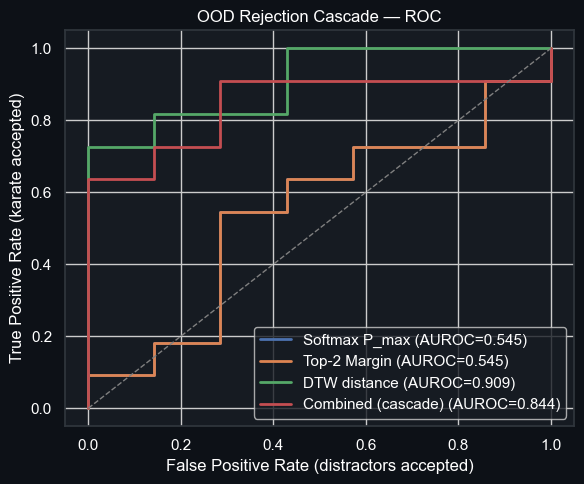

In [36]:
# ── §5.2 ROC curves + AUROC per score (and combined cascade score) ────────────
if not dist_present:
    print("⚠️ Skipping ROC — need distractor clips.")
else:
    # Combined acceptability score: normalize each signal to [0,1] where higher=more karate-like
    def norm(s, invert=False):
        v = (s - s.min()) / (s.max() - s.min() + 1e-9)
        return 1 - v if invert else v
    scores = {
        'Softmax P_max':  ood_df['pmax'],
        'Top-2 Margin':   ood_df['margin'],
        'DTW distance':   ood_df['dtw_min'],           # lower = more karate-like
        'Combined (cascade)': norm(ood_df['pmax']) * norm(ood_df['margin']) * norm(ood_df['dtw_min'], invert=True),
    }
    y = ood_df['label'].values
    fig, ax = plt.subplots(figsize=(6,5))
    for name, sc in scores.items():
        s = sc.values.astype(float)
        if name == 'DTW distance':                      # threshold on high distance = reject
            fpr, tpr, _ = roc_curve(y, -s)
        else:
            fpr, tpr, _ = roc_curve(y, s)
        au = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'{name} (AUROC={au:.3f})')
        print(f"{name}: AUROC = {au:.4f}")
    ax.plot([0,1],[0,1],'--', color='gray', lw=1)
    ax.set_xlabel('False Positive Rate (distractors accepted)')
    ax.set_ylabel('True Positive Rate (karate accepted)')
    ax.set_title('OOD Rejection Cascade — ROC')
    ax.legend(); plt.tight_layout()
    fig.savefig(RESULTS_DIR/'ood_roc.png', dpi=150, facecolor=fig.get_facecolor()); plt.show()
    ood_df.to_csv(RESULTS_DIR/'ood_scores.csv', index=False)


## §6 — DTW Feedback Replication (peak deviation, mirroring, mean-vs-max proof)
Replicates `compare_with_dtw` against the **new Master GT** with **stance routing**: `MaeGeri_*_standing` compares against `mae_geri_from_standing`, zenkutsu clips against `mae_geri_from_zenkutsu`. Also produces **Fig. 2 material**: the angle trajectory plot proving why mean error hides peak faults.



▶ GedanBarai_side_048_001.mov (standing GT):
   ✅ within tolerance on all 9 joints

▶ GedanBarai_side_048_002.mov (standing GT):
   • spine_lean: 25.8° off — user 112.7° vs master 87.4° (too extended/large)
   • right_knee: 22.6° off — user 123.7° vs master 146.1° (too bent/small)
   • left_knee: 22.6° off — user 113.1° vs master 91.7° (too extended/large)
   • left_shoulder: 20.8° off — user 65.6° vs master 45.5° (too extended/large)

▶ GedanBarai_side_049_001.mov (standing GT):
   • spine_lean: 92.5° off — user 79.9° vs master 178.8° (too bent/small)
   • right_elbow: 77.0° off — user 168.9° vs master 90.9° (too extended/large)
   • left_shoulder: 71.2° off — user 81.6° vs master 7.7° (too extended/large)
   • left_hip: 67.2° off — user 82.3° vs master 156.2° (too bent/small)

▶ GedanBarai_side_049_002.mov (standing GT):
   • right_elbow: 65.2° off — user 161.8° vs master 96.6° (too extended/large)
   • left_knee: 45.9° off — user 119.2° vs master 165.1° (too bent/small)
   • left_s

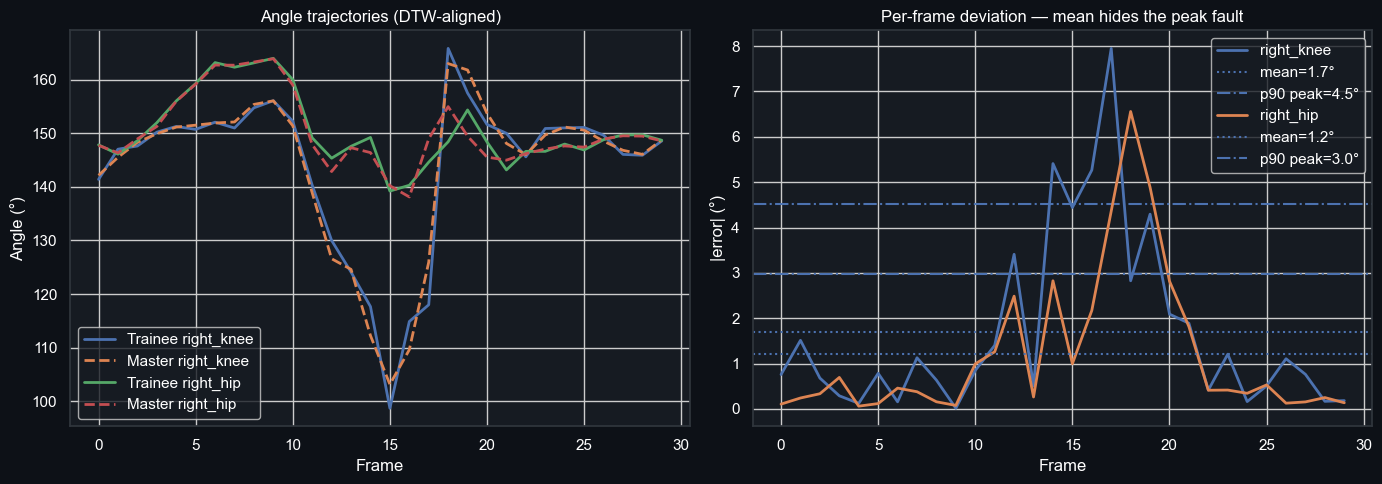

In [37]:
# ── §6.1 compare_with_dtw replica + mean-vs-max proof plot ────────────────────
ERROR_THRESHOLD = 12.0

def dtw_align(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf); D[0,0] = 0
    cost = np.abs(a[:,None,:] - b[None,:,:]).sum(-1)
    P = np.zeros((n+1, m+1))
    for i in range(1, n+1):
        for j in range(1, m+1):
            opts = [D[i-1,j], D[i,j-1], D[i-1,j-1]]
            D[i,j] = cost[i-1,j-1] + min(opts)
            P[i,j] = int(np.argmin(opts))
    path, i, j = [], n, m
    while i > 0 and j > 0:
        path.append((i-1, j-1))
        k = P[i,j]
        i, j = (i-1, j) if k==0 else (i, j-1) if k==1 else (i-1, j-1)
    return path[::-1]

def feedback_errors(rec):
    move = {'MaeGeri':'mae_geri','Gyakudzuki':'gyaku_zuki','GedanBarai':'gedan_barai'}[rec['gt_label']]
    key  = f"{move}_from_{rec['stance']}"
    ref  = np.array(master_gt[key]['angles'], np.float32)
    user = np.array([frame_angles_9(np.array([[l['x'],l['y'],l['z']] for l in f]))
                     for f in rec['frames']], np.float32)
    mir  = mirror9(user)
    d_o, d_m = _dtw_path(user, ref), _dtw_path(mir, ref)
    best = mir if d_m < d_o else user
    path = dtw_align(best, ref)
    ua = best[[p[0] for p in path]]; ra = ref[[p[1] for p in path]]
    diff = np.abs(ua - ra)
    peak = np.percentile(diff, 90, axis=0)                    # app uses p90 "peak deviation"
    errs = []
    for k, joint in enumerate(MASTER_ANGLE_NAMES):
        if peak[k] >= ERROR_THRESHOLD:
            ui = int(np.argmin(np.abs(diff[:,k] - peak[k])))
            errs.append({'joint': joint, 'mean_error': round(float(peak[k]),1),
                         'user_val': round(float(ua[ui,k]),1), 'ref_val': round(float(ra[ui,k]),1),
                         'direction': 'too extended/large' if ua[ui,k] > ra[ui,k] else 'too bent/small'})
    return sorted(errs, key=lambda e: e['mean_error'], reverse=True), user, ref, diff

all_feedback = {}
for rec in trainee_records:
    errs, u, r, diff = feedback_errors(rec)
    all_feedback[rec['video']] = errs
    print(f"\n▶ {rec['video']} ({rec['stance']} GT):")
    for e in errs[:4]:
        print(f"   • {e['joint']}: {e['mean_error']}° off — user {e['user_val']}° vs master {e['ref_val']}° ({e['direction']})")
    if not errs: print("   ✅ within tolerance on all 9 joints")

# Fig.2-style proof: mean error hides peak faults
vid = trainee_records[0]['video']; rec = trainee_records[0]
_, u, r, diff = feedback_errors(rec)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for j in [4, 6]:   # right_knee, right_hip
    axes[0].plot(u[:, j], lw=2, label=f'Trainee {MASTER_ANGLE_NAMES[j]}')
    axes[0].plot(r[:, j], lw=2, ls='--', label=f'Master {MASTER_ANGLE_NAMES[j]}')
axes[0].set_title('Angle trajectories (DTW-aligned)'); axes[0].set_xlabel('Frame'); axes[0].set_ylabel('Angle (°)'); axes[0].legend()
for j in [4, 6]:
    axes[1].plot(diff[:, j], lw=2, label=MASTER_ANGLE_NAMES[j])
    axes[1].axhline(diff[:, j].mean(), ls=':', label=f'mean={diff[:,j].mean():.1f}°')
    axes[1].axhline(np.percentile(diff[:, j], 90), ls='-.', label=f'p90 peak={np.percentile(diff[:,j],90):.1f}°')
axes[1].set_title('Per-frame deviation — mean hides the peak fault'); axes[1].set_xlabel('Frame'); axes[1].set_ylabel('|error| (°)'); axes[1].legend()
plt.tight_layout(); fig.savefig(RESULTS_DIR/'mean_vs_max_proof.png', dpi=150, facecolor=fig.get_facecolor()); plt.show()


## §7 — Feedback Quality Ablation (Reviewer A's demand)
Three arms, same DTW errors as input:
1. **Rule templates** — deterministic sentences from the error dicts (no LLM).
2. **Direct LLM** — raw errors → Groq `llama-3.3-70b-versatile`, no retrieval.
3. **RAG + LLM (ours)** — errors → ChromaDB retrieval (`coaching_chunks.json`) → grounded prompt.
If `GROQ_API_KEY` is absent, arms 2–3 fall back to a template so the notebook still runs end-to-end; the ablation table then only scores arm 1 + BLEU-like overlap.


In [40]:
# ── §7.1 Three feedback arms + offline fallback ───────────────────────────────
import os as _os

from dotenv import load_dotenv

from app.rag.retriever import retrieve                      # ChromaDB (same as app)
try:
    from app.rag.llm_client import generate_coaching_feedback
    GROQ_OK = bool(_os.getenv("GROQ_API_KEY"))
except Exception:
    GROQ_OK = False

JOINT_FIX = {
 'right_knee': "Extend the driving knee further through the technique's peak moment.",
 'left_knee':  "Check the support-leg knee — keep it stable and aligned.",
 'right_hip':  "Open the hip of the striking leg more at execution.",
 'left_hip':   "Keep the hips level; avoid dropping the support-side hip.",
 'right_elbow':'Tighten the chamber of the striking arm/elbow.',
 'left_elbow': "Control the counter-arm elbow.",
 'right_shoulder':'Drop tension from the striking-side shoulder.',
 'left_shoulder':'Keep the lead shoulder guarded and square.',
 'spine_lean': "Reduce torso lean — stay upright through the technique."}


def map_errors(errors):
    return [{'joint': e['joint'], 'query': e['direction'], 'user_val': e['user_val'], 'target_range': e['ref_val']} for e in errors]


def arm_rule(errors):
    if not errors: return "Clean rep — no joint exceeded the tolerance band."
    return " ".join(f"{e['joint'].replace('_',' ')} is {e['mean_error']}° {e['direction']}. {JOINT_FIX.get(e['joint'],'')}"
                    for e in errors[:3])

def arm_direct_llm(move, errors):
    if not GROQ_OK: return "[no API key] " + arm_rule(errors)
    return generate_coaching_feedback(move, map_errors(errors), retrieved_chunks=[])


def arm_rag_llm(move, errors):
    chunks = []
    for e in errors[:3]:
        chunks += retrieve(f"{move} {e['joint']} {e['direction']}", move=move.replace(' ', '_'), top_k=1)
    if not GROQ_OK:
        grounded = f"[offline RAG evidence] {chunks[0]['text'][:200]}" if chunks else ""
        return arm_rule(errors) + " " + grounded
    return generate_coaching_feedback(move, map_errors(errors), retrieved_chunks=chunks)

rows = []
for rec in trainee_records:
    errs = all_feedback[rec['video']]
    rows.append({'video': rec['video'],
                 'Rule template':      arm_rule(errs),
                 'Direct LLM':         arm_direct_llm(rec['gt_label'], errs)[:300],
                 'RAG+LLM (ours)':     arm_rag_llm(rec['gt_label'], errs)[:300],
                 'n_errors': len(errs)})
ablation_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 60)
display(ablation_df[['video','n_errors','Rule template','Direct LLM','RAG+LLM (ours)']])
ablation_df.to_csv(RESULTS_DIR/'feedback_ablation.csv', index=False)
if not GROQ_OK:
    print("\n⚠️ GROQ_API_KEY not set → Direct-LLM/RAG arms used offline fallback. Set the key & re-run this cell for real outputs.")
else:
    print("\n✅ Live Groq calls used for arms 2–3.")


[llm_client] Groq API error: NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.3-70b-versatile` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}
[llm_client] Falling back to plain-text coaching.
[llm_client] Groq API error: NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.3-70b-versatile` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}
[llm_client] Falling back to plain-text coaching.
[llm_client] Groq API error: NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.3-70b-versatile` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}
[llm_client] Falling back to plain-text coaching.


KeyError: 'mean_error'

## §8 — Paper-Ready Summary Export
Everything above is written to `Results/master_validation/`:
`clip_audit.csv`, `cv_results.csv`, `cv_fold_membership.csv`, `trainee9_classification.csv`,
`ood_scores.csv`, `ood_roc.png`, `mean_vs_max_proof.png`, `confusion_golden.png`, `feedback_ablation.csv`.


In [ ]:
# ── §8.1 One consolidated summary table ───────────────────────────────────────
summary = {
  'Dataset': f"{N_CLIPS} clips / {meta_df['practitioner_id'].nunique()} practitioners",
  'Train/Test split': f"{len(train_clips)} clips ({train_meta['practitioner_id'].nunique()} prac) / {len(test_clips)} clips ({test_meta['practitioner_id'].nunique()} prac)",
  'Leakage': 'ZERO (GroupKFold + golden override)',
  'CV Dual-Stem': cv_table.loc['Dual-Stem Fusion','Mean ± Std'],
  'CV Single Bi-LSTM': cv_table.loc['Single Bi-LSTM','Mean ± Std'],
  'CV XGBoost': cv_table.loc['XGBoost','Mean ± Std'],
  'CV Random Forest': cv_table.loc['Random Forest','Mean ± Std'],
  'Paired t-test p': f"{p_val:.4f}",
  'Academy 9-video acc (dual)': f"{acc_d:.1f}%",
  'OOD thresholds': f"τ₁={CONF_THR}, τ₂={MARGIN_THR}, τ₃={DTW_THR}°",
  'GT source': 'NEW isolated Master videos (Savitzky-Golay w=5, stance-specific keys)',
}
for k, v in summary.items(): print(f"{k:32s}: {v}")
print("\n🎉 Notebook complete — attach Results/master_validation/ figures to the resubmission.")
